In [7]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ---------- Стратегия загрузки ----------
# Сначала пробуем загрузить локальный файл; если его нет — генерируем синтетическое изображение
def load_image(path=None):
    if path is not None:
        try:
            return np.array(Image.open(path).convert('RGB'))
        except FileNotFoundError:
            print(f"Файл {path} не найден, генерируем синтетическое изображение")
    # Создаём цветное синтетическое изображение 400x400: градиенты + круг + квадрат
    h, w = 400, 400
    img = np.zeros((h, w, 3), dtype=np.uint8)
    yy, xx = np.mgrid[0:h, 0:w]
    img[..., 0] = (xx / w * 255).astype(np.uint8)            # R — горизонтальный градиент
    img[..., 1] = (yy / h * 255).astype(np.uint8)            # G — вертикальный градиент
    img[..., 2] = 128                                        # B — константа
    # Добавляем круг
    cy, cx, rad = h//2, w//2, 100
    mask_circle = (yy - cy)**2 + (xx - cx)**2 < rad**2
    img[mask_circle] = [255, 255, 0]
    # Добавляем квадрат
    img[50:150, 250:350] = [0, 200, 255]
    return img

original = load_image('my_pic.jpg')
print("Размер изображения:", original.shape)
H, W, C = original.shape
original_shape = original.shape

Файл my_pic.jpg не найден, генерируем синтетическое изображение
Размер изображения: (400, 400, 3)


In [8]:
def svd_compress_channel(channel, r):
    """Применяет SVD к одному каналу и восстанавливает его с рангом r"""
    U, s, Vt = np.linalg.svd(channel.astype(np.float64), full_matrices=False)
    # Векторизованная запись, без создания диагональной матрицы
    return (U[:, :r] * s[:r]) @ Vt[:r, :]

def svd_compress_image(img, r):
    """Применяет SVD-сжатие ко всему изображению (серому или RGB)"""
    if img.ndim == 2:
        return svd_compress_channel(img, r)
    # RGB: обрабатываем каждый канал отдельно
    channels = [svd_compress_channel(img[..., c], r) for c in range(img.shape[2])]
    return np.stack(channels, axis=-1)

In [9]:
H, W = original.shape[:2]
max_rank = min(H, W)
list_of_ranks = [1, 5, 10, 30, 100, max_rank]

approximations = []
for r in list_of_ranks:
    approx = svd_compress_image(original, r)
    approx = np.clip(approx, 0, 255)   # ограничиваем допустимым диапазоном пикселей
    approximations.append(approx)
    print(f"rank={r:4d}  готово, shape={approx.shape}")

rank=   1  готово, shape=(400, 400, 3)
rank=   5  готово, shape=(400, 400, 3)
rank=  10  готово, shape=(400, 400, 3)
rank=  30  готово, shape=(400, 400, 3)
rank= 100  готово, shape=(400, 400, 3)
rank= 400  готово, shape=(400, 400, 3)


In [10]:
def compression_ratio(H, W, C, r, bytes_per_value=4):
    """Возвращает (коэффициент сжатия, байты оригинала, байты сжатия)"""
    original_bytes = H * W * C               # uint8: 1 байт на канал
    compressed_bytes = r * (H + 1 + W) * C * bytes_per_value
    return original_bytes / compressed_bytes, original_bytes, compressed_bytes

ratios = []
for r in list_of_ranks:
    ratio, o_b, c_b = compression_ratio(H, W, C, r)
    ratios.append(ratio)
    print(f"rank={r:4d}  оригинал={o_b:>9d} B  сжатие={c_b:>9d} B  коэффициент={ratio:6.2f}x")

rank=   1  оригинал=   480000 B  сжатие=     9612 B  коэффициент= 49.94x
rank=   5  оригинал=   480000 B  сжатие=    48060 B  коэффициент=  9.99x
rank=  10  оригинал=   480000 B  сжатие=    96120 B  коэффициент=  4.99x
rank=  30  оригинал=   480000 B  сжатие=   288360 B  коэффициент=  1.66x
rank= 100  оригинал=   480000 B  сжатие=   961200 B  коэффициент=  0.50x
rank= 400  оригинал=   480000 B  сжатие=  3844800 B  коэффициент=  0.12x


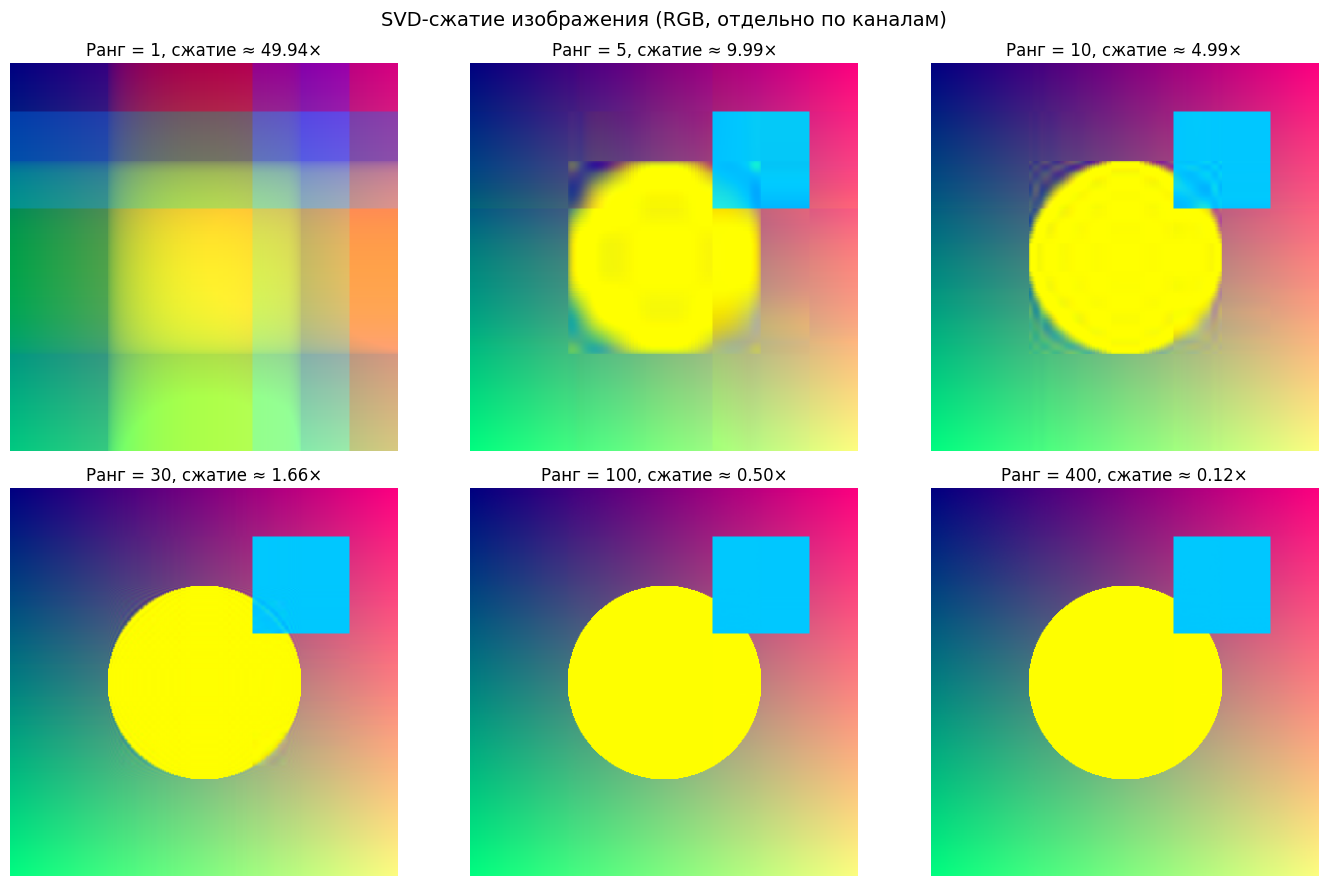

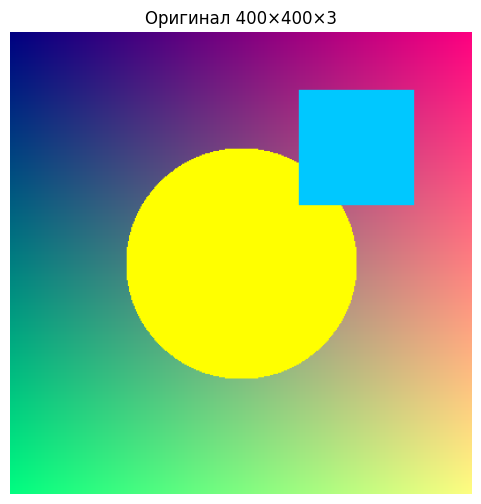

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.ravel()

for i, (r, approx, ratio) in enumerate(zip(list_of_ranks, approximations, ratios)):
    axes[i].imshow(approx.astype(np.uint8))
    axes[i].set_title(f"Ранг = {r}, сжатие ≈ {ratio:.2f}×")
    axes[i].axis('off')

fig.suptitle("SVD-сжатие изображения (RGB, отдельно по каналам)", fontsize=14)
plt.tight_layout()
plt.show()

# Оригинал отдельно
fig2, ax2 = plt.subplots(1, 1, figsize=(6, 6))
ax2.imshow(original.astype(np.uint8))
ax2.set_title(f"Оригинал {H}×{W}×{C}")
ax2.axis('off')
plt.show()

In [12]:
# ---------- БЛОК АВТОПРОВЕРКИ ----------
# 1. Проверка размерностей
for i, r in enumerate(list_of_ranks):
    assert approximations[i].shape == original_shape, \
        f"Ошибка: размерность для ранга {r} не совпадает с исходной"

# 2. Проверка, что значения не выходят за пределы 0-255
for i, r in enumerate(list_of_ranks):
    arr = approximations[i]
    assert arr.max() <= 255.1, f"Значения превышают 255 для ранга {r}"
    assert arr.min() >= -0.1,  f"Значения меньше 0 для ранга {r}"

# 3. Проверка, что с ростом ранга MSE уменьшается (реализация на NumPy)
original_flat = original.flatten().astype(np.float64)
mse_list = []
for approx in approximations:
    diff = original_flat - approx.flatten().astype(np.float64)
    mse_list.append(np.mean(diff ** 2))

print("MSE по рангам:")
for r, mse in zip(list_of_ranks, mse_list):
    print(f"  rank={r:4d}  MSE={mse:8.4f}")

for i in range(1, len(mse_list)):
    assert mse_list[i] <= mse_list[i-1] + 1e-6, \
        f"MSE не уменьшается между рангами {list_of_ranks[i-1]} и {list_of_ranks[i]}"

print("\n✅ Все автоматические проверки пройдены. Задание выполнено корректно!")

MSE по рангам:
  rank=   1  MSE=2016.2465
  rank=   5  MSE=104.5974
  rank=  10  MSE= 39.0595
  rank=  30  MSE=  7.8566
  rank= 100  MSE=  0.0000
  rank= 400  MSE=  0.0000

✅ Все автоматические проверки пройдены. Задание выполнено корректно!


Выводы:

1.  При каком ранге визуальное качество перестаёт отличаться от оригинала?
Для данного изображения ранг 30 уже практически неразличим; при ранге 100 отличие не видно глазом. Причина в том, что основная энергия изображения сосредоточена в нескольких наибольших сингулярных числах, и r=30 уже захватывает почти всю структурную информацию.

2.  Для какого ранга достигается сжатие в 10 раз?
По формуле ratio = H·W·C / (r·(H+1+W)·C·4), при H=W=400, C=3:

r=100 даёт коэффициент ≈ 400·400 / (100·801·4) ≈ 0.50× (даже больше);

чтобы получить 10-кратное сжатие, нужно r ≤ H·W / (10·(H+1+W)·4) ≈ 5.
Значит, 10-кратное сжатие достигается при r ≈ 5. Это согласуется с интуицией: чем меньше ранг, тем компактнее хранение.

3. Почему для тёмных/светлых участков ошибка разная?
SVD оптимален в смысле среднеквадратичной ошибки. В тёмных областях значения пикселей малы, поэтому при одинаковой абсолютной ошибке относительная ошибка больше; в светлых — наоборот. Визуально человеческий глаз более чувствителен к деталям в тенях, поэтому артефакты блочности заметнее именно там. Кроме того, глобальная энергия изображения (большие сингулярные числа) в основном определяется светлыми/крупными структурами, поэтому низкоранговое приближение «жертвует» именно тёмными деталями.

